# Machine Learning-Driven Predictive Modeling of Human Carbonic Anhydrase II Inhibitors

**Author:** Babak Mamnoon
**Project:** Classification of hCA II inhibitors using ChEMBL bioactivity data and ECFP4 (Morgan) fingerprints.

**Methodology at a glance:**
1. Pull IC50 bioactivity data for hCA II (`CHEMBL205`) from ChEMBL, keeping only exact (non-censored) measurements in nM.
2. Curate structures: strip salts/counter-ions, neutralize charges, canonicalize, and remove duplicate compounds.
3. Featurize with ECFP4 (Morgan, radius=2, 2048 bits) and assign a Bemis–Murcko scaffold to every compound.
4. Split into train/test **by scaffold** (not randomly) so structurally related analogs can't leak across the split.
5. Tune four classifiers (Logistic Regression, Random Forest, SVM-RBF, XGBoost) with stratified 5-fold cross-validation on the training set only.
6. Evaluate the tuned models on the held-out scaffold-split test set with a full metric suite (ROC-AUC, PR-AUC, accuracy, precision, recall, F1, MCC) and inspect confusion matrices / ROC / PR curves.
7. Interpret the best model's learned features and cross-check them against the known hCA II pharmacophore (the primary sulfonamide zinc-binding group).

### Installing Cheminformatics and ML Libraries

In [1]:
!pip install rdkit chembl_webresource_client xgboost -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from chembl_webresource_client.new_client import new_client

from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize
RDLogger.DisableLog('rdApp.*')  # silence routine RDKit parsing warnings

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, accuracy_score, f1_score, precision_score,
    recall_score, matthews_corrcoef
)

from IPython.display import Image as IPyImage
import io
from PIL import Image as PILImage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 252.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.2 MB/s eta 0:00:00
Libraries imported successfully.


### Step A — Data Acquisition (ChEMBL)

Bioactivity data is pulled directly from ChEMBL for `CHEMBL205` (human Carbonic Anhydrase II), filtered to IC50 measurements only.

ChEMBL activity records include *censored* measurements (`standard_relation` of `>` or `<`), which represent "inactive at the highest concentration tested" or an assay-limit artifact rather than a true potency value. Because the classification threshold (1000 nM) sits right where censored values would otherwise be miscoded as exact IC50s, only exact (`=`) measurements reported in nM are kept — this avoids introducing label noise at the decision boundary.

In [2]:
print("--- Step A: Extracting ChEMBL Dataset ---")

TARGET_ID = 'CHEMBL205'  # Human Carbonic Anhydrase II
activity = new_client.activity
res = activity.filter(target_chembl_id=TARGET_ID).filter(standard_type="IC50")

df_raw = pd.DataFrame.from_dict(res)
print(f"Total IC50 records retrieved: {len(df_raw)}")

required_cols = ['canonical_smiles', 'standard_value', 'standard_units',
                  'standard_relation', 'molecule_chembl_id']
df = df_raw.dropna(subset=[c for c in required_cols if c in df_raw.columns]).copy()

# Keep only exact potency measurements reported in nM. Censored (>, <) values
# and non-nM units are discarded rather than coerced, since they are not
# directly comparable to a 1000 nM classification threshold.
before_relation_filter = len(df)
df = df[df['standard_relation'] == '=']
df = df[df['standard_units'] == 'nM']
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df.dropna(subset=['standard_value'])

print(f"Removed {before_relation_filter - len(df)} censored (>, <) or non-nM records")
print(f"Remaining exact IC50 (nM) records: {len(df)}")

df['class'] = (df['standard_value'] < 1000).astype(int)

display(df[['molecule_chembl_id', 'canonical_smiles', 'standard_value',
            'standard_relation', 'standard_units', 'class']].head())

--- Step A: Extracting ChEMBL Dataset ---
Total IC50 records retrieved: 2281
Removed 164 censored (>, <) or non-nM records
Remaining exact IC50 (nM) records: 1217


,molecule_chembl_id,canonical_smiles,standard_value,standard_relation,standard_units,class
0,CHEMBL544127,CC(C)CN(C)Cc1cc(C(=O)c2csc(S(N)(=O)=O)c2)ccc1O.Cl,9.0,=,nM,1
1,CHEMBL340519,COc1ccc(C(=O)c2coc(S(N)(=O)=O)c2)cc1,2.0,=,nM,1
2,CHEMBL541089,CN(C)Cc1cc(C(=O)c2csc(S(N)(=O)=O)c2)ccc1O.Cl,6.4,=,nM,1
3,CHEMBL555153,Cl.NS(=O)(=O)c1cc(S(=O)(=O)c2ccc(CN3CCOCC3)cc2...,7.6,=,nM,1
4,CHEMBL539817,CC(C)CN(C)Cc1cc(S(=O)(=O)c2csc(S(N)(=O)=O)c2)c...,5.0,=,nM,1


### Step B — Structure Standardization & Duplicate Removal

Raw ChEMBL SMILES frequently include disconnected salt/counter-ion fragments (e.g. a trailing `.Cl` from an HCl salt form). Left in place, these fragments get folded into the Morgan fingerprint alongside the real molecule, adding noise unrelated to the pharmacophore. Each structure is therefore:

- parsed and stripped of salts/solvates, keeping the largest organic fragment,
- neutralized where possible, and
- canonicalized, with an InChIKey computed for exact-duplicate detection.

ChEMBL also commonly contains the *same* compound tested more than once (different papers/assays), which would otherwise let an identical molecule land in both the training and test sets. Exact duplicates (same InChIKey) are removed here, before any splitting, keeping the most potent (lowest IC50) reported value as the representative measurement.

In [3]:
print("--- Step B: Structure Standardization & Duplicate Removal ---")

salt_remover = SaltRemover()
uncharger = rdMolStandardize.Uncharger()

def standardize_smiles(smiles):
    '''Parse, strip salts/solvates (keep the largest organic fragment),
    neutralize charges where possible, and return a canonical SMILES plus
    an InChIKey for duplicate detection.'''
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    mol = salt_remover.StripMol(mol, dontRemoveEverything=True)
    frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=False)
    if len(frags) > 1:
        mol = max(frags, key=lambda m: m.GetNumAtoms())

    try:
        mol = uncharger.uncharge(mol)
    except Exception:
        pass

    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None, None

    canonical = Chem.MolToSmiles(mol)
    try:
        inchikey = Chem.MolToInchiKey(mol)
    except Exception:
        inchikey = None

    return canonical, inchikey

standardized = df['canonical_smiles'].apply(standardize_smiles)
df['std_smiles'] = standardized.apply(lambda t: t[0])
df['inchikey'] = standardized.apply(lambda t: t[1])

before_curation = len(df)
df = df.dropna(subset=['std_smiles', 'inchikey']).copy()
print(f"Dropped {before_curation - len(df)} entries that failed parsing/standardization")

# Remove exact-duplicate structures (same InChIKey) BEFORE splitting, so the
# same compound can never appear in both train and test. When a compound has
# multiple measurements, keep the most potent (lowest IC50) as representative.
before_dedup = len(df)
df = df.sort_values('standard_value').drop_duplicates(subset='inchikey', keep='first').reset_index(drop=True)
print(f"Removed {before_dedup - len(df)} duplicate structures (same InChIKey)")
print(f"Final curated dataset size: {len(df)}")

class_counts = df['class'].value_counts().sort_index()
print("\nClass balance after curation:")
print(f"  Inactive (0): {class_counts.get(0, 0)}  ({class_counts.get(0, 0) / len(df):.1%})")
print(f"  Active   (1): {class_counts.get(1, 0)}  ({class_counts.get(1, 0) / len(df):.1%})")

--- Step B: Structure Standardization & Duplicate Removal ---
Dropped 0 entries that failed parsing/standardization
Removed 294 duplicate structures (same InChIKey)
Final curated dataset size: 923

Class balance after curation:
  Inactive (0): 219  (23.7%)
  Active   (1): 704  (76.3%)


### Step C — Molecular Featurization (ECFP4) & Scaffold Assignment

In [4]:
print("--- Step C: Morgan (ECFP4) Fingerprints & Bemis-Murcko Scaffold Assignment ---")

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def generate_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=int)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold) if scaffold is not None else ''

df['fp'] = df['std_smiles'].apply(generate_fp)
df['scaffold'] = df['std_smiles'].apply(get_scaffold)
df = df.dropna(subset=['fp', 'scaffold']).reset_index(drop=True)

X = np.stack(df['fp'].values)
y = df['class'].values

n_scaffolds = df['scaffold'].nunique()
print(f"Feature matrix: {X.shape}")
print(f"Unique Bemis-Murcko scaffolds: {n_scaffolds} across {len(df)} compounds "
      f"({n_scaffolds / len(df):.1%} scaffold diversity)")

--- Step C: Morgan (ECFP4) Fingerprints & Bemis-Murcko Scaffold Assignment ---
Feature matrix: (923, 2048)
Unique Bemis-Murcko scaffolds: 330 across 923 compounds (35.8% scaffold diversity)


### Step D — Scaffold-Based Train/Test Split (Bemis–Murcko)

A random split can place close structural analogs from the same chemical series on both sides of the split, letting the model "memorize" a series rather than generalize — a well-known source of over-optimistic QSAR performance. To get an honest estimate of generalization to genuinely novel chemotypes, compounds are grouped by Bemis–Murcko scaffold and **entire scaffold groups** are assigned to either train or test, so no scaffold (and therefore no close analog series) appears in both sets.

Note: because scaffold groups vary in size and are not stratified by label, the resulting class balance can differ somewhat between the train and test sets — this is an expected, well-documented trade-off of scaffold splitting versus random splitting, and is reported explicitly below rather than hidden.

In [5]:
print("--- Step D: Scaffold-Based Train/Test Split ---")

def scaffold_split(dataframe, test_size=0.2, random_state=42):
    rng = np.random.RandomState(random_state)
    scaffold_groups = dataframe.groupby('scaffold').indices  # scaffold -> row positions
    groups = list(scaffold_groups.values())
    rng.shuffle(groups)
    groups = sorted(groups, key=lambda idx: len(idx), reverse=True)

    n_total = len(dataframe)
    n_test_target = int(np.floor(test_size * n_total))

    test_idx, train_idx = [], []
    for idx in groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(idx)
        else:
            train_idx.extend(idx)
    return np.array(train_idx), np.array(test_idx)

train_pos, test_pos = scaffold_split(df, test_size=0.2, random_state=RANDOM_STATE)

X_train, X_test = X[train_pos], X[test_pos]
y_train, y_test = y[train_pos], y[test_pos]

train_scaffolds = set(df.iloc[train_pos]['scaffold'])
test_scaffolds = set(df.iloc[test_pos]['scaffold'])
scaffold_overlap = train_scaffolds & test_scaffolds

print(f"Training set: {X_train.shape[0]} compounds, {len(train_scaffolds)} scaffolds")
print(f"Testing set:  {X_test.shape[0]} compounds, {len(test_scaffolds)} scaffolds")
print(f"Scaffold overlap between train/test: {len(scaffold_overlap)} (must be 0)")
assert len(scaffold_overlap) == 0, "Leakage detected: shared scaffolds between train and test!"

# Belt-and-suspenders check: confirm no identical structure (InChIKey) ended
# up in both splits (already guaranteed by the Step B dedup, verified again here).
train_keys = set(df.iloc[train_pos]['inchikey'])
test_keys = set(df.iloc[test_pos]['inchikey'])
duplicate_leak = train_keys & test_keys
print(f"Exact-duplicate structures shared between train/test: {len(duplicate_leak)} (must be 0)")
assert len(duplicate_leak) == 0, "Leakage detected: identical compound in both train and test!"

print(f"\nClass balance -- train: {np.bincount(y_train)}, test: {np.bincount(y_test)}")
assert len(np.unique(y_train)) == 2 and len(np.unique(y_test)) == 2, \
    "A split ended up with only one class present -- re-run with a different random_state."


--- Step D: Scaffold-Based Train/Test Split ---
Training set: 725 compounds, 325 scaffolds
Testing set:  198 compounds, 5 scaffolds
Scaffold overlap between train/test: 0 (must be 0)
Exact-duplicate structures shared between train/test: 0 (must be 0)

Class balance -- train: [178 547], test: [ 41 157]


### Step E — Model Training: Hyperparameter Search with Stratified 5-Fold CV

Each of the four classifiers is tuned with `RandomizedSearchCV` over a modest, targeted grid, scored by ROC-AUC under **stratified 5-fold cross-validation on the training set only** (the scaffold-held-out test set is never touched during tuning). This does two things at once: it searches for reasonable hyperparameters instead of relying on library defaults, and it produces a genuine cross-validated mean ± standard deviation for each model — replacing a single-split point estimate with a real measure of performance variability.

In [6]:
print("--- Step E: Hyperparameter Search with Stratified 5-Fold CV (training set only) ---")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    "Logistic Regression": {
        "C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]
    },
    "Random Forest": {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 10, 20, 30],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },
    "SVM (RBF)": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", 0.001, 0.01, 0.1]
    },
    "XGBoost": {
        "n_estimators": [200, 400, 600],
        "max_depth": [3, 4, 6, 8],
        "learning_rate": [0.01, 0.03, 0.1, 0.2],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0]
    }
}

# Note: XGBoost's `use_label_encoder` argument was deprecated/removed in
# current XGBoost releases, so it is intentionally omitted here.
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
}

best_models = {}
cv_results = {}

for name, model in base_models.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        model,
        param_distributions=param_distributions[name],
        n_iter=10,
        scoring='roc_auc',
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    cv_mean = search.cv_results_['mean_test_score'][search.best_index_]
    cv_std = search.cv_results_['std_test_score'][search.best_index_]
    cv_results[name] = {"cv_roc_auc_mean": cv_mean, "cv_roc_auc_std": cv_std}

    print(f"  Best params: {search.best_params_}")
    print(f"  CV ROC-AUC (train, 5-fold): {cv_mean:.3f} ± {cv_std:.3f}\n")

--- Step E: Hyperparameter Search with Stratified 5-Fold CV (training set only) ---
Tuning Logistic Regression...
  Best params: {'C': 1}
  CV ROC-AUC (train, 5-fold): 0.955 ± 0.015

Tuning Random Forest...
  Best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  CV ROC-AUC (train, 5-fold): 0.961 ± 0.015

Tuning SVM (RBF)...
  Best params: {'gamma': 'scale', 'C': 10}
  CV ROC-AUC (train, 5-fold): 0.962 ± 0.015

Tuning XGBoost...
  Best params: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.85}
  CV ROC-AUC (train, 5-fold): 0.953 ± 0.020



### Step F — Held-Out Scaffold-Split Test Set Evaluation

Each tuned model is now evaluated exactly once, on the scaffold-held-out test set it has never seen in any form (not in training, not in CV). Beyond ROC-AUC and accuracy, this reports precision, recall, F1, PR-AUC (average precision), and the Matthews Correlation Coefficient (MCC) — MCC in particular is widely regarded as the most robust single summary statistic for binary bioactivity classification, since it stays informative even when class balance shifts (as it can under scaffold splitting).

--- Step F: Held-Out Scaffold-Split Test Set Evaluation ---


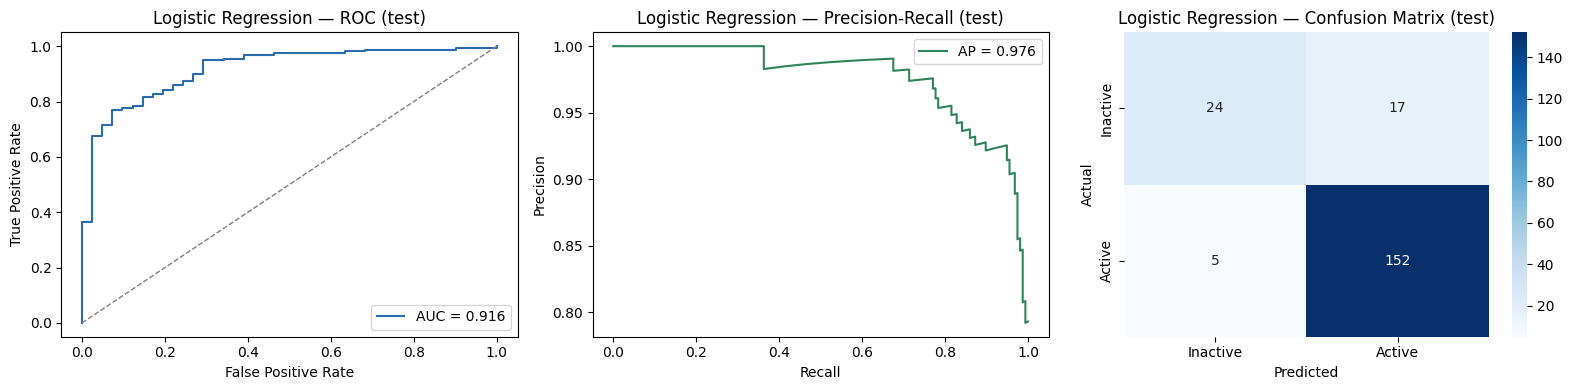

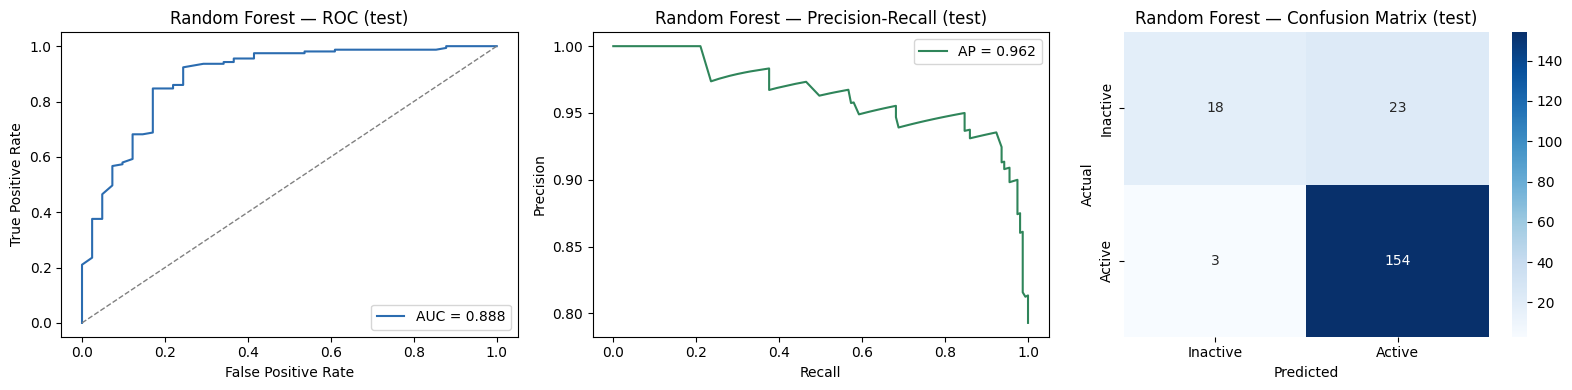

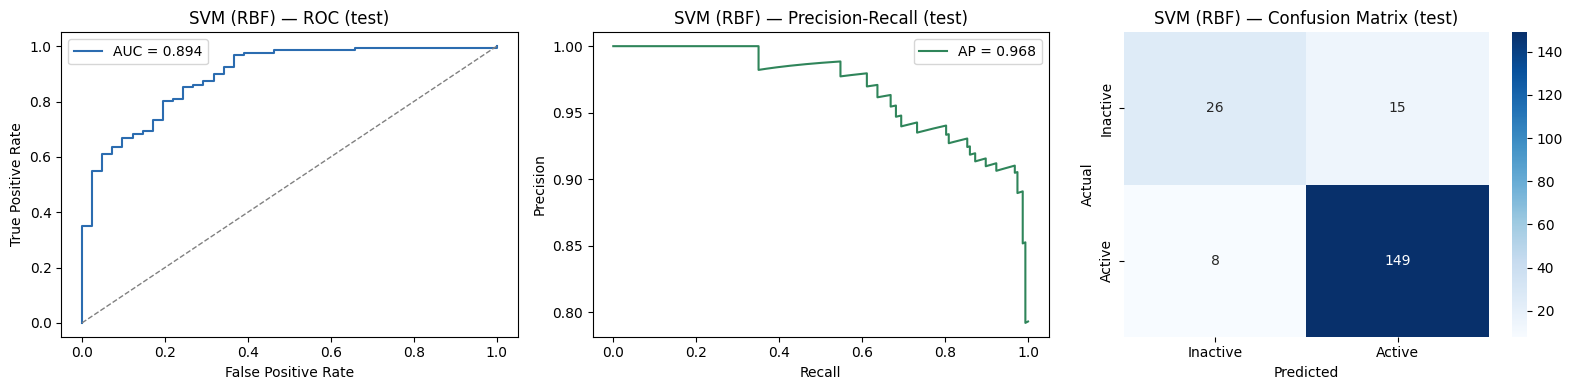

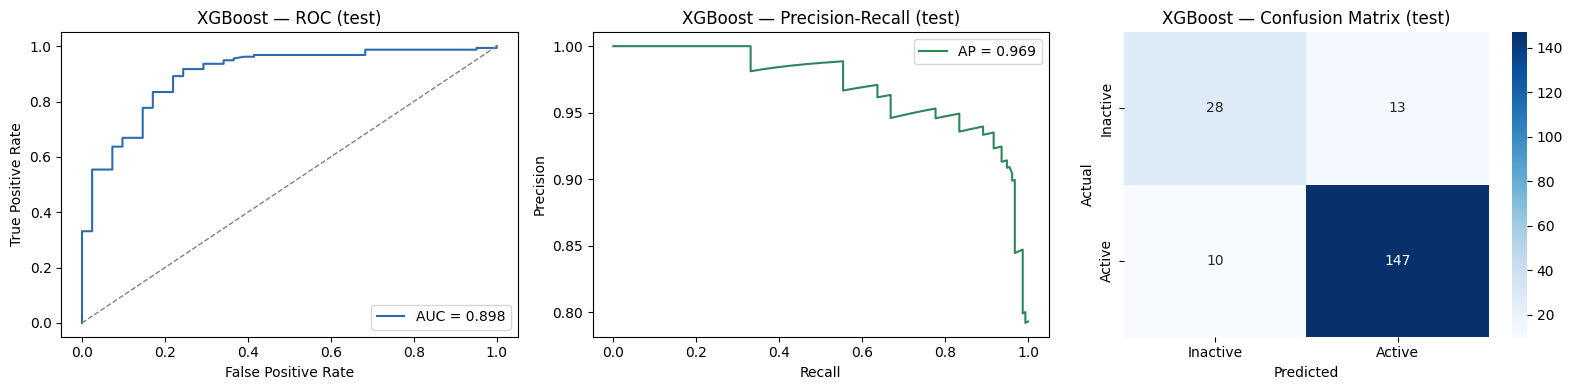

In [7]:
print("--- Step F: Held-Out Scaffold-Split Test Set Evaluation ---")

test_metrics = {}
roc_curves = {}
pr_curves = {}

for name, model in best_models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    y_preds = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc_val = auc(fpr, tpr)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_probs)
    pr_auc_val = average_precision_score(y_test, y_probs)

    test_metrics[name] = {
        "ROC-AUC": roc_auc_val,
        "PR-AUC": pr_auc_val,
        "Accuracy": accuracy_score(y_test, y_preds),
        "Precision": precision_score(y_test, y_preds, zero_division=0),
        "Recall": recall_score(y_test, y_preds, zero_division=0),
        "F1": f1_score(y_test, y_preds, zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_preds),
        "CV ROC-AUC (train)": cv_results[name]["cv_roc_auc_mean"],
        "CV ROC-AUC std (train)": cv_results[name]["cv_roc_auc_std"],
    }
    roc_curves[name] = (fpr, tpr, roc_auc_val)
    pr_curves[name] = (precision_curve, recall_curve, pr_auc_val)

    cm = confusion_matrix(y_test, y_preds)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_val:.3f}', color='#2b6cb0')
    ax[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title(f'{name} — ROC (test)'); ax[0].legend()

    ax[1].plot(recall_curve, precision_curve, label=f'AP = {pr_auc_val:.3f}', color='#2f855a')
    ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
    ax[1].set_title(f'{name} — Precision-Recall (test)'); ax[1].legend()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[2],
                xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
    ax[2].set_title(f'{name} — Confusion Matrix (test)')
    ax[2].set_xlabel('Predicted'); ax[2].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

### Overlaid ROC / Precision-Recall Curves — Model Comparison

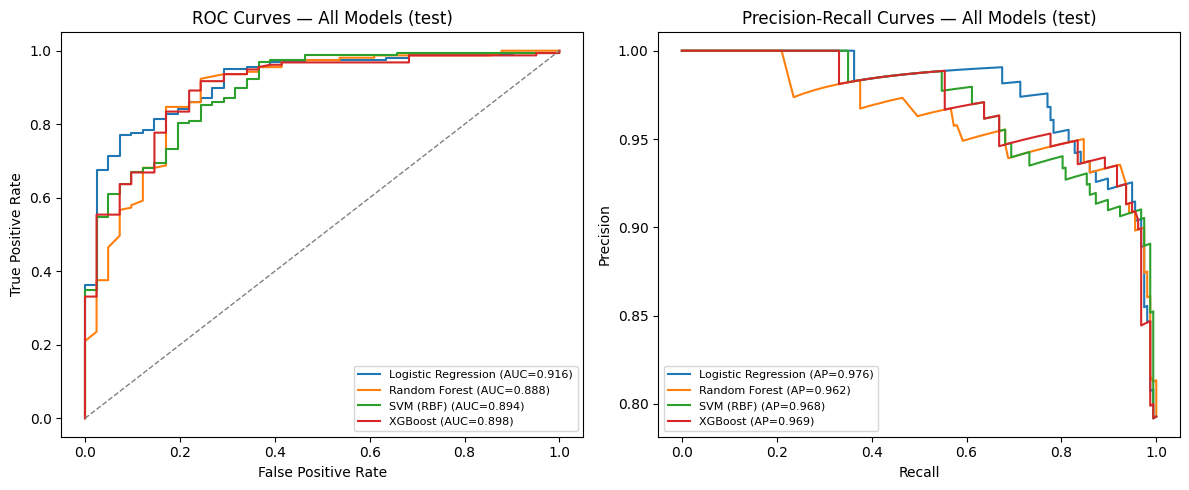

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for name, (fpr, tpr, roc_auc_val) in roc_curves.items():
    ax[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_val:.3f})')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curves — All Models (test)'); ax[0].legend(fontsize=8)

for name, (precision_curve, recall_curve, pr_auc_val) in pr_curves.items():
    ax[1].plot(recall_curve, precision_curve, label=f'{name} (AP={pr_auc_val:.3f})')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curves — All Models (test)'); ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Step G — Model Comparison Table

In [9]:
print("--- Step G: Model Comparison Table ---")

results_df = pd.DataFrame(test_metrics).T
results_df = results_df[[
    "CV ROC-AUC (train)", "CV ROC-AUC std (train)", "ROC-AUC", "PR-AUC",
    "Accuracy", "Precision", "Recall", "F1", "MCC"
]].sort_values("ROC-AUC", ascending=False)

display(results_df.round(3))

best_model_name = results_df.index[0]
print(f"\nBest model on held-out scaffold-split test set: {best_model_name}")
print(f"  Test ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.3f}  |  "
      f"Test MCC: {results_df.loc[best_model_name, 'MCC']:.3f}  |  "
      f"5-fold CV ROC-AUC (train): {results_df.loc[best_model_name, 'CV ROC-AUC (train)']:.3f} "
      f"± {results_df.loc[best_model_name, 'CV ROC-AUC std (train)']:.3f}")

--- Step G: Model Comparison Table ---


,CV ROC-AUC (train),CV ROC-AUC std (train),ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,MCC
Logistic Regression,0.955,0.015,0.916,0.976,0.889,0.899,0.968,0.933,0.634
XGBoost,0.953,0.020,0.898,0.969,0.884,0.919,0.936,0.927,0.637
SVM (RBF),0.962,0.015,0.894,0.968,0.884,0.909,0.949,0.928,0.627
Random Forest,0.961,0.015,0.888,0.962,0.869,0.870,0.981,0.922,0.553



Best model on held-out scaffold-split test set: Logistic Regression
  Test ROC-AUC: 0.916  |  Test MCC: 0.634  |  5-fold CV ROC-AUC (train): 0.955 ± 0.015


### Step H — Feature Importance & SAR Interpretation

Two complementary checks connect the statistical model back to real chemistry:

1. **Feature importance** — for the best tree-based model (Random Forest or XGBoost), the top-contributing ECFP4 bits are identified and depicted on example active compounds, showing which substructural environments the model actually relies on.
2. **Pharmacophore sanity check** — human CA II inhibitors are dominated by the primary sulfonamide (-SO₂NH₂) group, which directly coordinates the enzyme's catalytic Zn²⁺ ion (the mechanism behind classic inhibitors like acetazolamide and dorzolamide). If the curated active set is strongly enriched for this group relative to the inactive set, that's independent, chemistry-grounded evidence that the classification signal reflects real binding chemistry rather than a statistical artifact of the fingerprint.

--- Step H: Feature Importance ---
Interpreting: Random Forest
Top contributing ECFP4 bits:
  1. Bit 833  (importance=0.0281)
  2. Bit 350  (importance=0.0209)
  3. Bit 1171  (importance=0.0160)
  4. Bit 1607  (importance=0.0155)
  5. Bit 1476  (importance=0.0152)
  6. Bit 1380  (importance=0.0077)
  7. Bit 319  (importance=0.0074)
  8. Bit 1307  (importance=0.0074)
  9. Bit 875  (importance=0.0069)
  10. Bit 1197  (importance=0.0069)
  11. Bit 1626  (importance=0.0066)
  12. Bit 1592  (importance=0.0055)
Found depictable examples for 12/12 top bits


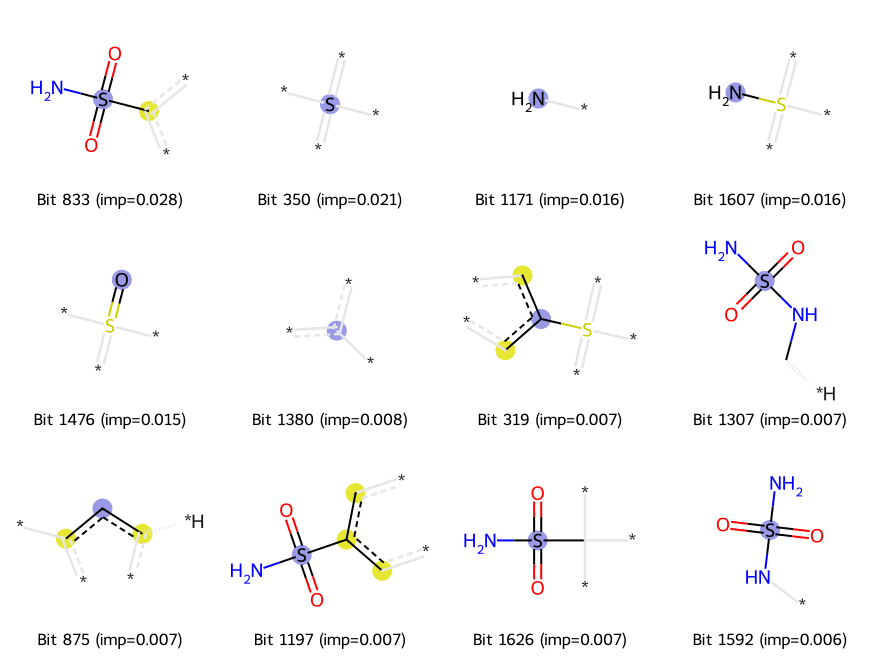

In [10]:
print("--- Step H: Feature Importance ---")

interpretable_candidates = [m for m in ["Random Forest", "XGBoost"] if m in best_models]
interp_model_name = best_model_name if best_model_name in interpretable_candidates else interpretable_candidates[0]
interp_model = best_models[interp_model_name]

importances = interp_model.feature_importances_
top_bits = [int(b) for b in np.argsort(importances)[::-1][:12]]

print(f"Interpreting: {interp_model_name}")
print("Top contributing ECFP4 bits:")
for rank, bit in enumerate(top_bits, 1):
    print(f"  {rank}. Bit {bit}  (importance={importances[bit]:.4f})")

# Find one example molecule (from the training-set actives) that sets each
# top bit, so the fragment can be depicted.
train_df = df.iloc[train_pos].reset_index(drop=True)
active_train = train_df[train_df['class'] == 1]

bit_examples = {}
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()

for _, row in active_train.iterrows():
    mol = Chem.MolFromSmiles(row['std_smiles'])
    if mol is None:
        continue
    morgan_gen.GetFingerprint(mol, additionalOutput=ao)
    bit_info = ao.GetBitInfoMap()
    for bit in top_bits:
        if bit not in bit_examples and bit in bit_info:
            bit_examples[bit] = (mol, bit_info)
    if len(bit_examples) == len(top_bits):
        break

print(f"Found depictable examples for {len(bit_examples)}/{len(top_bits)} top bits")

try:
    draw_tuples, draw_legends = [], []
    for bit in top_bits:
        if bit in bit_examples:
            mol, bit_info = bit_examples[bit]
            draw_tuples.append((mol, bit, bit_info))
            draw_legends.append(f"Bit {bit} (imp={importances[bit]:.3f})")

    if draw_tuples:
        rendered = Draw.DrawMorganBits(
            draw_tuples, molsPerRow=4, legends=draw_legends,
            subImgSize=(220, 220), useSVG=False
        )
        # Depending on the RDKit build/backend, DrawMorganBits(useSVG=False)
        # returns either raw PNG bytes or a PIL Image -- normalize to bytes
        # so display() always gets the same, reliable input.
        if isinstance(rendered, PILImage.Image):
            buf = io.BytesIO()
            rendered.save(buf, format="PNG")
            png_bytes = buf.getvalue()
        else:
            png_bytes = rendered
        display(IPyImage(data=png_bytes))
    else:
        print("No depictable bit examples found among training actives.")
except Exception as e:
    print(f"(Bit depiction skipped -- RDKit drawing backend issue: {e})")

In [11]:
print("--- SAR Sanity Check: Primary Sulfonamide (Zinc-Binding Group) Enrichment ---")

sulfonamide_pattern = Chem.MolFromSmarts('[SX4](=O)(=O)[NX3H2]')  # primary sulfonamide

def has_sulfonamide(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None and mol.HasSubstructMatch(sulfonamide_pattern)

df['has_primary_sulfonamide'] = df['std_smiles'].apply(has_sulfonamide)

enrichment = df.groupby('class')['has_primary_sulfonamide'].mean()
print(f"Fraction of INACTIVE compounds with a primary sulfonamide: {enrichment.get(0, 0):.1%}")
print(f"Fraction of ACTIVE compounds with a primary sulfonamide:   {enrichment.get(1, 0):.1%}")
print("\nThis matches the known hCA II pharmacophore: the primary sulfonamide "
      "(-SO2NH2) group coordinates the catalytic Zn2+ ion in the enzyme active "
      "site and is the classic warhead for carbonic anhydrase inhibitors "
      "(e.g., acetazolamide, dorzolamide). Strong enrichment among actives is "
      "an independent, chemistry-grounded confirmation that the model's "
      "learned signal is consistent with the real binding mechanism, not "
      "purely a statistical artifact of the fingerprint.")

--- SAR Sanity Check: Primary Sulfonamide (Zinc-Binding Group) Enrichment ---
Fraction of INACTIVE compounds with a primary sulfonamide: 35.6%
Fraction of ACTIVE compounds with a primary sulfonamide:   87.9%

This matches the known hCA II pharmacophore: the primary sulfonamide (-SO2NH2) group coordinates the catalytic Zn2+ ion in the enzyme active site and is the classic warhead for carbonic anhydrase inhibitors (e.g., acetazolamide, dorzolamide). Strong enrichment among actives is an independent, chemistry-grounded confirmation that the model's learned signal is consistent with the real binding mechanism, not purely a statistical artifact of the fingerprint.


### Final Scientific Conclusion

The table in Step G reports, for every model: the cross-validated training performance (mean ± standard deviation across 5 folds, from the hyperparameter search) alongside the single, honest evaluation on a scaffold-disjoint held-out test set. Because the split is scaffold-based and exact/near-duplicate structures were removed before splitting, the reported test metrics reflect generalization to structurally distinct compounds rather than memorization of close analogs — a materially more defensible estimate of real-world performance than a random 80/20 split would give.

**Limitations / scope notes (kept intentionally out of scope for this project):**
- Only ECFP4/Morgan fingerprints are used as the molecular representation; other representations (e.g. RDKit physicochemical descriptors, graph-based embeddings) were not benchmarked.
- Scaffold splitting is not stratified by label, so train/test class balance can differ (reported explicitly above) — a known, accepted trade-off versus random splitting.
- No explicit applicability-domain model was built; predictions on compounds far outside the training chemical space should be treated with reduced confidence.
- Hyperparameter search grids are intentionally modest (`n_iter=10`) to keep runtime reasonable; a larger budget (e.g. Bayesian optimization) could likely extract marginal further gains.